In [17]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import  DataLoader
from torchvision import transforms ,models ,datasets
from torchvision.utils import make_grid
import os
from PIL import Image
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np

In [18]:
Train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


Test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
     transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),

])



In [39]:
root = "../CNN_Image_Classification/CATS_DOGS"
train_data= datasets.ImageFolder(os.path.join(root,"train"),transform=Train_transform)
test_data= datasets.ImageFolder(os.path.join(root,"test"),transform=Train_transform)

torch.manual_seed(42)
train_loader=DataLoader(train_data,batch_size=10, shuffle=True)
test_loader = DataLoader(test_data,batch_size=10,shuffle=True)
DataLoader(test_data,batch_size=10, shuffle=True)



In [20]:
class_names = train_data.classes

In [21]:
len(train_data)

18743

In [22]:
len(test_data)

6251

Label: [1 1 0 1 1 1 1 0 0 1]
class :  ['DOG' 'DOG' 'CAT' 'DOG' 'DOG' 'DOG' 'DOG' 'CAT' 'CAT' 'DOG']


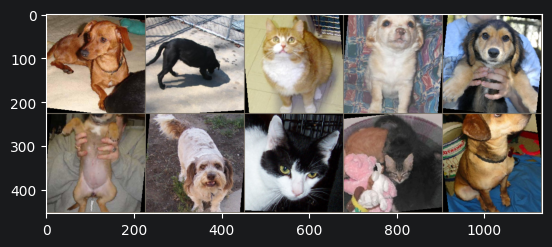

In [26]:
for images,labels in train_loader:
    break

print("Label:",labels.numpy())
print("class : ", np.array([class_names[i] for i in labels]))


im=make_grid(images,nrow=5)
inv_normazation = transforms.Normalize(mean=[-0.485/0.229, -0.456/.224,-0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
inv=inv_normazation(im)
plt.imshow(np.transpose(inv.numpy(), (1, 2, 0)))
plt.show()

Classes: ['CAT', 'DOG']
Class to Index Mapping:
{'CAT': 0, 'DOG': 1}


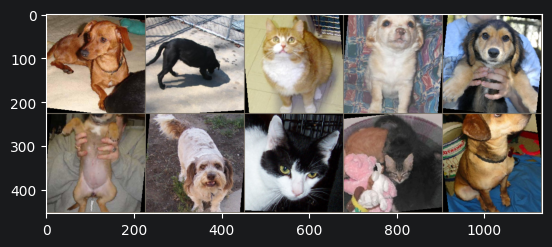

In [28]:
# another way by ChatGPT

from torchvision import datasets
import os

root = "../CNN_Image_Classification/CATS_DOGS"

train_data = datasets.ImageFolder(
    os.path.join(root, "train")
)

# Check class names
print("Classes:", train_data.classes)

# Check label mapping
print("Class to Index Mapping:")
print(train_data.class_to_idx)
im=make_grid(images,nrow=5)
inv_normazation = transforms.Normalize(mean=[-0.485/0.229, -0.456/.224,-0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
inv=inv_normazation(im)
plt.imshow(np.transpose(inv.numpy(), (1, 2, 0)))
plt.show()

In [29]:
class convolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 3,1)
        self.conv2=nn.Conv2d(6,16,3,1)
        self.fc1=nn.Linear(54*54*16,120)
        self.fc2=nn.Linear(120, 84)
        self.fc3=nn.Linear(84, 2)
    def forward(self, X):
        X = F.relu(self.conv1(X))
        X=F.max_pool2d(X,2,2)
        X = F.relu(self.conv2(X))
        X=F.max_pool2d(X,2,2)
        X=X.view(-1,54*54*16)
        X=F.relu(self.fc1(X))
        X=F.relu(self.fc2(X))
        X=self.fc3(X)

        return F.log_softmax(X,dim=1)

In [30]:
import torch

# Check GPU availability
print("GPU Available:", torch.cuda.is_available())

# GPU count
print("Number of GPUs:", torch.cuda.device_count())

# GPU name
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

GPU Available: True
Number of GPUs: 1
GPU Name: NVIDIA GeForce RTX 2050


## instantiate the model , define loss, and optimazation functions\


In [31]:
torch.manual_seed(42)
CNNModel= convolutionalNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(CNNModel.parameters(), lr=0.001)
CNNModel

convolutionalNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=46656, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
)

### trainable parameters

In [35]:
params = [p.numel() for p in CNNModel.parameters() if p.requires_grad]
for item in params:
    print(f'{item:>8}')


     162
       6
     864
      16
 5598720
     120
   10080
      84
     168
       2


In [36]:
params

[162, 6, 864, 16, 5598720, 120, 10080, 84, 168, 2]

In [37]:
sum(params)

5610222

### train the model

In [47]:
import time
start_time=time.time()

epochs=5
max_trn_batch=800
max_tst_batch=300

train_losses =[]
test_losses =[]
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr=0
    tst_corr=0
    for b, (X_train,Y_train) in enumerate(train_loader):

        if b==max_trn_batch:
            break
        b=b+1

        y_pred =CNNModel(X_train)
        loss=criterion(y_pred,Y_train)

        predicted =torch.max(y_pred.data,1)[1]
        batch_corr=(predicted == Y_train).sum()
        trn_corr+=batch_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if b%200==0:
            print(f"Epoch : {i:2} batch: {b:4} [{10*b:6}/8000] loss: {loss.item():10.8f} accuracy:{ trn_corr.item()*100/(10*b) :7.3f}%")
    train_losses.append(loss.item())
    train_correct.append(trn_corr)


    with torch.no_grad():
        for b , (X_test,Y_test) in enumerate(test_loader):
            if b==max_tst_batch:
                break

            y_val =CNNModel(X_test)

            predicted =torch.max(y_val.data,1)[1]
            tst_corr+=(predicted == Y_test).sum()
    loss= criterion(y_val,Y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)




Epoch :  0 batch:  200 [  2000/8000] loss: 0.38460770 accuracy: 77.750%
Epoch :  0 batch:  400 [  4000/8000] loss: 0.30776674 accuracy: 76.600%
Epoch :  0 batch:  600 [  6000/8000] loss: 0.40440327 accuracy: 76.850%
Epoch :  0 batch:  800 [  8000/8000] loss: 0.31864148 accuracy: 77.188%
Epoch :  1 batch:  200 [  2000/8000] loss: 0.63227761 accuracy: 76.900%
Epoch :  1 batch:  400 [  4000/8000] loss: 0.75214630 accuracy: 77.350%
Epoch :  1 batch:  600 [  6000/8000] loss: 0.46880394 accuracy: 77.267%
Epoch :  1 batch:  800 [  8000/8000] loss: 0.42379174 accuracy: 77.412%
Epoch :  2 batch:  200 [  2000/8000] loss: 0.31966501 accuracy: 78.700%
Epoch :  2 batch:  400 [  4000/8000] loss: 0.29146940 accuracy: 78.850%
Epoch :  2 batch:  600 [  6000/8000] loss: 0.64930415 accuracy: 78.600%
Epoch :  2 batch:  800 [  8000/8000] loss: 0.59920895 accuracy: 78.100%
Epoch :  3 batch:  200 [  2000/8000] loss: 0.23720582 accuracy: 79.200%
Epoch :  3 batch:  400 [  4000/8000] loss: 0.37905857 accuracy: 

In [50]:
# save the model

torch.save(CNNModel.state_dict(),"CustomerCNNModel.pt")

TypeError: 'float' object is not callable

## Pretrain Model provided by torchVision

In [68]:


AlexNet = models.alexnet(pretrained=True)

# Replace ONLY the final layer
AlexNet.classifier[6] = nn.Linear(4096, 2)

In [62]:
for param in AlexNet.parameters():
    param.requires_grad =True

In [63]:
torch.manual_seed(42)
AlexNet.classifier =nn.Sequential(nn.Linear(9216,4096),nn.ReLU(),nn.Dropout(0.4),nn.Linear(1024,2),
                                  nn.LogSoftmax(dim=1))

AlexNet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Linear(in_features=9216, out_features=4096, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, 

In [64]:
params = [p.numel() for p in AlexNet.parameters() if p.requires_grad]
for item in params:
    print(f'{item:>8}')

   23232
      64
  307200
     192
  663552
     384
  884736
     256
  589824
     256
37748736
    4096
    2048
       2


In [65]:
torch.manual_seed(42)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(AlexNet.classifier.parameters(), lr=0.001)


In [70]:
import time
start_time=time.time()

epochs=10
max_trn_batch=800
max_tst_batch=300

train_losses =[]
test_losses =[]
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr=0
    tst_corr=0
    for b, (X_train,Y_train) in enumerate(train_loader):

        if b==max_trn_batch:
            break
        b=b+1

        y_pred =AlexNet(X_train)
        loss=criterion(y_pred,Y_train)

        predicted =torch.max(y_pred.data,1)[1]
        batch_corr=(predicted == Y_train).sum()
        trn_corr+=batch_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if b%200==0:
            print(f"Epoch : {i:2} batch: {b:4} [{10*b:6}/8000] loss: {loss.item():10.8f} accuracy:{ trn_corr.item()*100/(10*b) :7.3f}%")
    train_losses.append(loss.item())
    train_correct.append(trn_corr)


    with torch.no_grad():
        for b , (X_test,Y_test) in enumerate(test_loader):
            if b==max_tst_batch:
                break

            y_val =AlexNet(X_test)

            predicted =torch.max(y_val.data,1)[1]
            tst_corr+=(predicted == Y_test).sum()
    loss= criterion(y_val,Y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)


Epoch :  0 batch:  200 [  2000/8000] loss: 0.94718397 accuracy: 29.550%
Epoch :  0 batch:  400 [  4000/8000] loss: 1.44461679 accuracy: 29.150%
Epoch :  0 batch:  600 [  6000/8000] loss: 1.21057057 accuracy: 29.733%
Epoch :  0 batch:  800 [  8000/8000] loss: 1.07724190 accuracy: 29.575%
Epoch :  1 batch:  200 [  2000/8000] loss: 1.37731707 accuracy: 30.700%
Epoch :  1 batch:  400 [  4000/8000] loss: 1.10980058 accuracy: 30.900%
Epoch :  1 batch:  600 [  6000/8000] loss: 1.08005548 accuracy: 30.050%
Epoch :  1 batch:  800 [  8000/8000] loss: 1.24234116 accuracy: 29.863%
Epoch :  2 batch:  200 [  2000/8000] loss: 1.22633696 accuracy: 30.150%
Epoch :  2 batch:  400 [  4000/8000] loss: 1.30777073 accuracy: 29.275%
Epoch :  2 batch:  600 [  6000/8000] loss: 1.05894244 accuracy: 28.817%
Epoch :  2 batch:  800 [  8000/8000] loss: 0.90110129 accuracy: 29.100%


KeyboardInterrupt: 

### Run a new image on the model

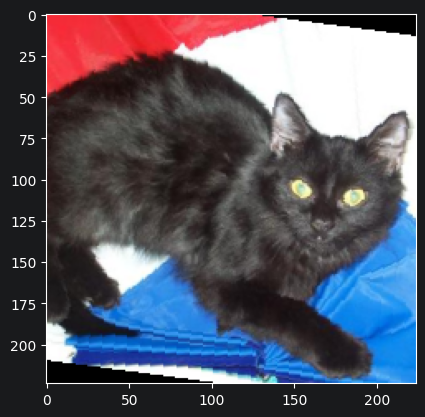

In [73]:
i = 2026

im = inv_normazation(test_data[i][0])

plt.imshow(np.transpose(im.numpy(), (1,2,0)))

plt.show()

In [74]:
test_data[i][0].shape

torch.Size([3, 224, 224])

In [76]:
## CNN model prediction
CNNModel.eval()
with torch.no_grad():
    pred = CNNModel(test_data[i][0].view(1,3,224,224)).argmax()
print(f"Predicted class: {pred.item()}{class_names[pred.item()]}]")

Predicted class: 0CAT]


In [82]:
cute = Image.open("cute.png")



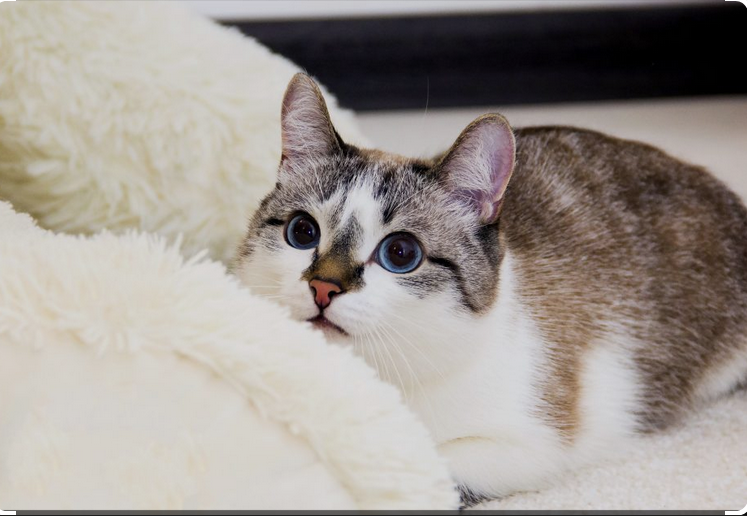

In [83]:
cute

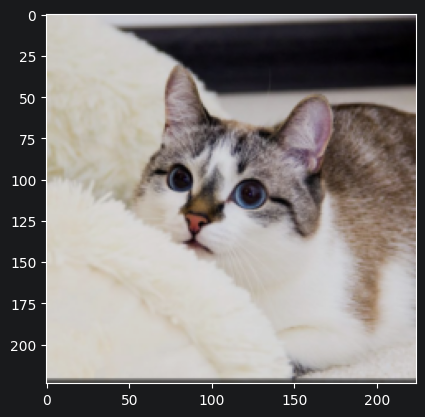

In [88]:
cute = cute.convert("RGB")

cute_norm = Test_transform(cute)

im = inv_normazation(cute_norm)

plt.imshow(np.transpose(im.numpy(), (1,2,0)))

plt.show()

In [90]:
im.shape

torch.Size([3, 224, 224])

In [91]:
CNNModel.eval()
with torch.no_grad():
    pred=CNNModel(im.view(1,3,224,224)).argmax()

print(f"Predicted class: {pred.item()}{class_names[pred.item()]}]")


Predicted class: 0CAT]
